Lab 5&6

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [29]:
df=pd.read_csv("Ecommerce Customers.csv")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


EDA

In [30]:
print("First 5 rows:")
display(df.head())

print("\nInfo about dataset:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing values per column:")
display(df.isna().sum())

First 5 rows:


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092



Info about dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB
None

Statistical Summary:


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462



Missing values per column:


Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

Feature Engineering

In [31]:
#price related
df['Yearly_Spent_per_Session'] = df['Yearly Amount Spent'] / df['Avg. Session Length']

# 4.2 Membership-related
df['Spend_per_Membership_Year'] = df['Yearly Amount Spent'] / df['Length of Membership']

# 4.3 Encode categorical using One-Hot Encoding
avatar_ohe = pd.get_dummies(df['Avatar'], prefix='Avatar')
df = pd.concat([df, avatar_ohe], axis=1)

print("Feature Engineering Completed.")

Feature Engineering Completed.


Prepare Features (X) and target (Y)

In [32]:
X= df.drop(columns=['Email', 'Address', 'Avatar', 'Yearly Amount Spent'])
y = df['Yearly Amount Spent']

print("Feature matrix X and target y prepared.")

Feature matrix X and target y prepared.


Train and test split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (400, 144), Test shape: (100, 144)


Scaling numeric features 

In [34]:
numeric_features = ['Avg. Session Length', 'Time on App', 'Time on Website',
                    'Length of Membership', 'Yearly_Spent_per_Session', 'Spend_per_Membership_Year']

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Numeric features scaled.")

Numeric features scaled.


Create and Trrain Linear Regression Model

In [35]:
lr_model= LinearRegression()
lr_model.fit(X_train,y_train)
print("Linear Regression Model Trained Successfully.")

Linear Regression Model Trained Successfully.


Predictions

In [36]:
y_pred = lr_model.predict(X_test)
print("Predictions Completed.")

Predictions Completed.


Evaluation Metrics

In [37]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")


Model Evaluation Metrics:
MAE: 1.80
MSE: 5.97
RMSE: 2.44
R2 Score: 1.00


Visualization

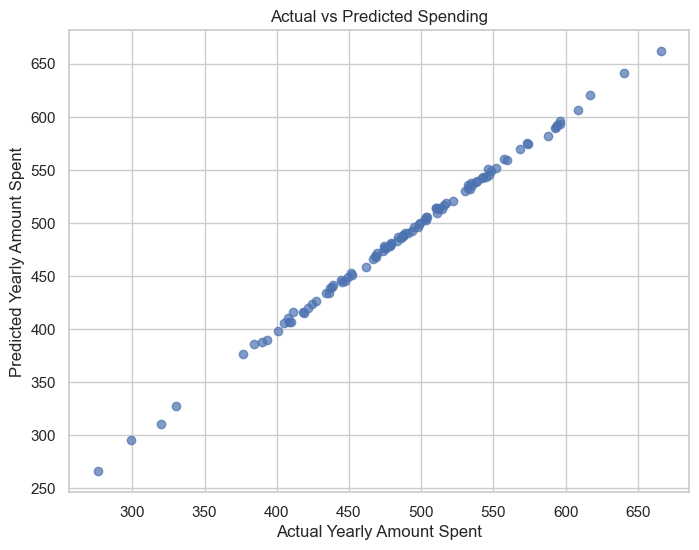

In [38]:
#Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Yearly Amount Spent")
plt.ylabel("Predicted Yearly Amount Spent")
plt.title("Actual vs Predicted Spending")
plt.show()

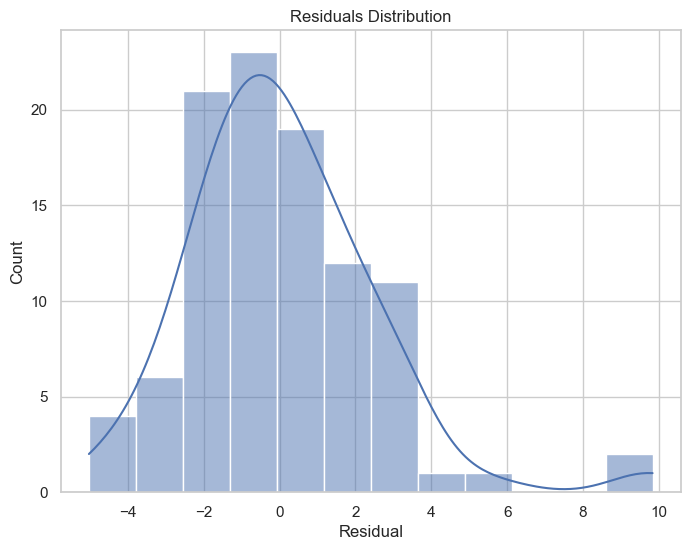

In [39]:
#Residuals Distribution
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.show()